In [ ]:
# ===============================
# Download Dataset
# ===============================

import kagglehub
path = kagglehub.dataset_download("imranbukhari/comprehensive-btcusd-1m-data", output_dir="dataset/")
print("Path to dataset files:", path)

Path to dataset files: dataset/


In [ ]:
# ===============================
# Load Dataset
# ===============================

import pandas as pd
df = pd.read_csv("dataset/BTCUSD_1m_Binance.csv", usecols=['Open time','Close'])
df.columns = ['time', 'price']
df.head()

,time,price
0,2017-08-17 04:00:00,4261.48
1,2017-08-17 04:01:00,4261.48
2,2017-08-17 04:02:00,4280.56
3,2017-08-17 04:03:00,4261.48
4,2017-08-17 04:04:00,4261.48


In [ ]:
# ===============================
# Data Refinemend and Resampling
# ===============================

df['time'] = pd.to_datetime(df['time'])
time_series = df.set_index('time')

time_series = time_series.resample('D').last().dropna()

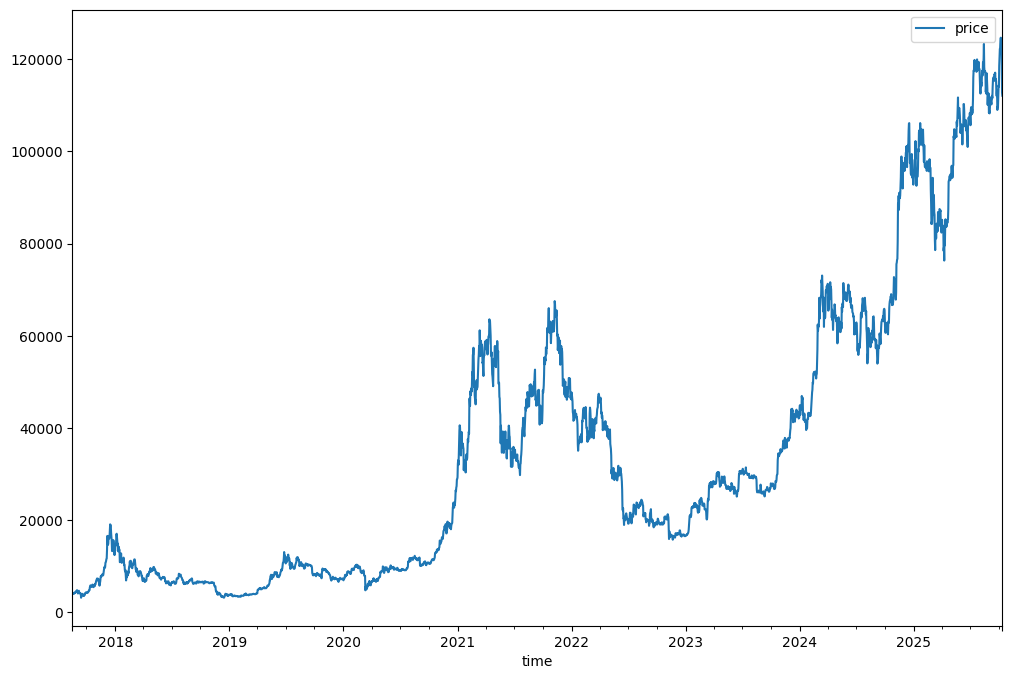

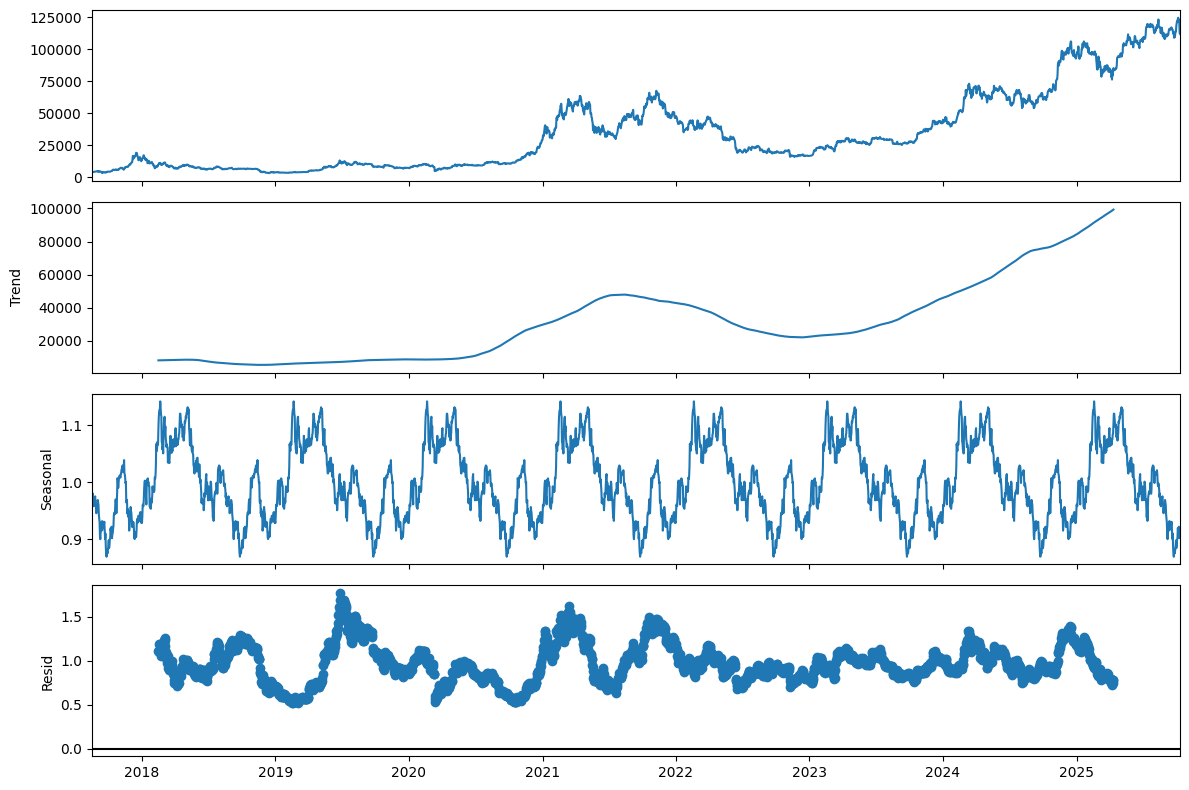

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import seasonal_decompose

plt.rcParams['figure.figsize'] = (12, 8)
# ===========================
# Data Vizualization
# ===========================
time_series.plot(y='price')

# ===========================
# Seasonal Decomposition
# ===========================

decompose = seasonal_decompose(time_series, model='multiplicative', period=365)
decompose.plot();

In [ ]:
from statsforecast import StatsForecast
from statsforecast.models import MSTL, AutoARIMA

pipeline = StatsForecast(
    models=[MSTL(season_length=[7, 30, 90, 120 ,365, 365*4],)],
                 freq='D',
                 n_jobs=-1
)

In [ ]:
time_series_df = pd.DataFrame({
    'ds':time_series.index,
    'y':time_series['price'],
    'unique_id':'time_series'
})

pipeline.fit(time_series_df)

StatsForecast(models=[MSTL])

In [ ]:
time_series_df['ds']

time
2017-08-17   2017-08-17
2017-08-18   2017-08-18
2017-08-19   2017-08-19
2017-08-20   2017-08-20
2017-08-21   2017-08-21
                ...    
2025-10-07   2025-10-07
2025-10-08   2025-10-08
2025-10-09   2025-10-09
2025-10-10   2025-10-10
2025-10-11   2025-10-11
Freq: D, Name: ds, Length: 2978, dtype: datetime64[us]

In [ ]:
decompose_data = pipeline.fitted_[0,0].model_
decompose_data['ds'] = time_series.index

In [ ]:
decompose_data

,data,trend,seasonal7,seasonal30,seasonal90,seasonal120,seasonal365,seasonal1460,remainder,ds
0,4285.08,691.252907,-53.554026,82.429934,425.814734,1326.986960,-3788.320452,19855.890740,-14255.420797,2017-08-17
1,4108.37,711.456941,-115.839859,368.271455,274.929471,1520.003401,-3950.608481,20055.347519,-14755.190447,2017-08-18
2,4139.98,731.656332,116.755144,122.372959,573.928933,1154.074864,-3977.535001,20429.599836,-15010.873066,2017-08-19
3,4086.29,751.851077,59.426767,48.334790,528.041345,1401.063107,-4145.391528,21026.527318,-15583.562876,2017-08-20
4,4016.00,772.041174,22.478104,207.869790,710.895984,1372.288286,-4099.143782,20487.215266,-15457.644823,2017-08-21
...,...,...,...,...,...,...,...,...,...,...
2973,121332.95,86996.573885,-110.511518,-743.751212,-1870.279379,199.493615,-1655.809729,25685.443802,12831.790537,2025-10-07
2974,123306.00,87043.475489,1156.885065,196.513835,-1166.679623,51.620160,-1719.363510,25763.427852,11980.120732,2025-10-08
2975,121662.40,87090.382498,431.727262,55.423852,-754.198023,56.237589,-2183.058652,26030.695415,10935.190058,2025-10-09
2976,112774.50,87137.294905,-789.256413,-548.735676,-1153.831028,-166.747403,-2840.543659,24761.560934,6374.758339,2025-10-10


array([<Axes: xlabel='ds'>, <Axes: xlabel='ds'>, <Axes: xlabel='ds'>,
       <Axes: xlabel='ds'>, <Axes: xlabel='ds'>, <Axes: xlabel='ds'>,
       <Axes: xlabel='ds'>, <Axes: xlabel='ds'>, <Axes: xlabel='ds'>],
      dtype=object)

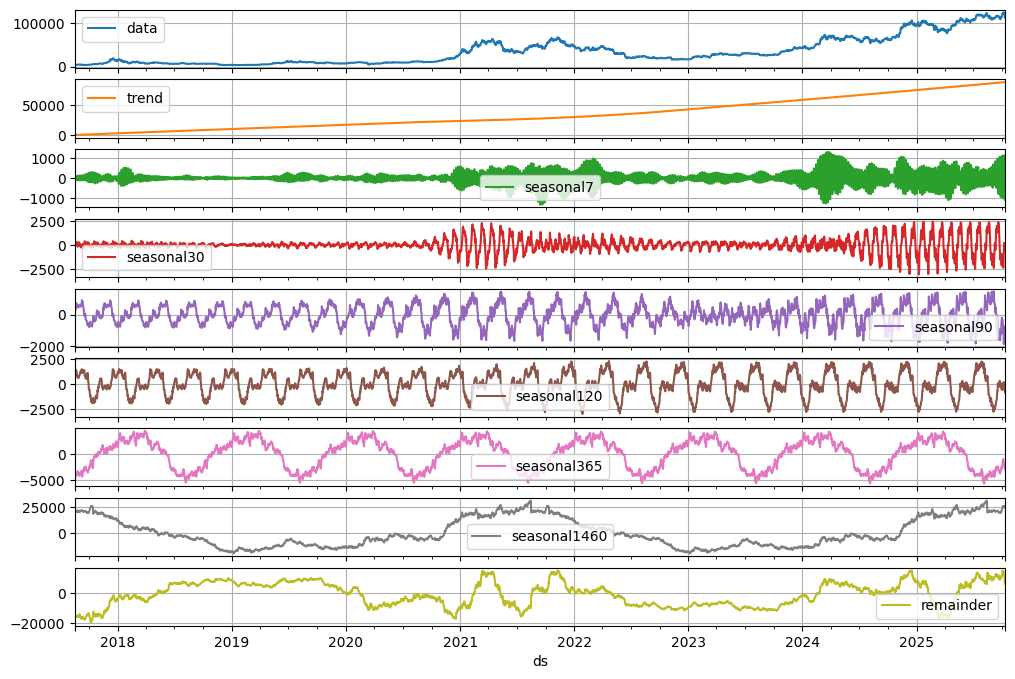

In [ ]:
decompose_data.plot(x='ds', subplots=True, grid=True)

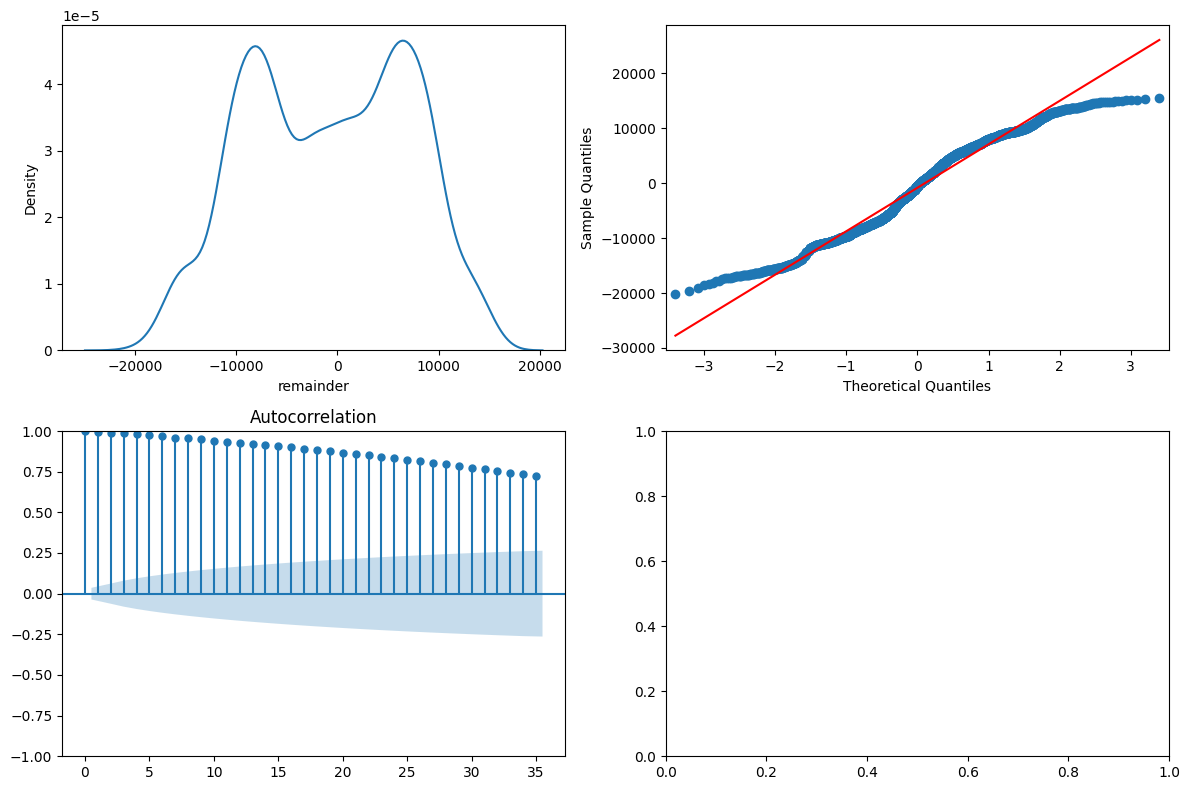

In [ ]:
from statsmodels.api import qqplot
fig, axs = plt.subplots(2, 2)
sns.kdeplot(decompose_data['remainder'], ax=axs[0, 0], label='Residuals')
qqplot(decompose_data['remainder'], ax=axs[0, 1], line='s')
plot_acf(decompose_data['remainder'], ax=axs[1, 0])

fig.tight_layout()

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera
acorr_ljungbox(decompose_data['remainder'])
jarque_bera(decompose_data['remainder'])

(np.float64(138.9056539761091),
 np.float64(6.871008511194858e-31),
 np.float64(-0.07255454900952325),
 np.float64(1.9519551942022002))

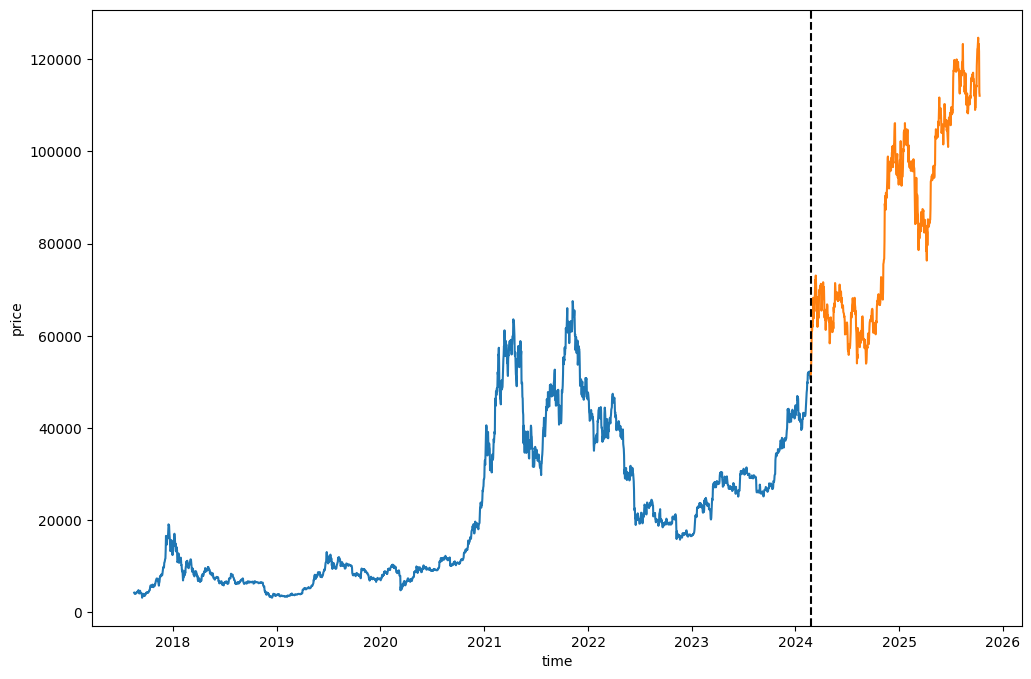

In [ ]:
# ========================
# Train-Test Split
# ========================

train_ratio = 0.8
split_index = int(len(time_series)*train_ratio)
train, test = time_series.iloc[:split_index], time_series.iloc[split_index:]

# ==============================
# Train Test Visualization
# ==============================

fig, ax = plt.subplots(1,1)
sns.lineplot(train,x=train.index,  y='price', ax=ax)
sns.lineplot(test,x=test.index,  y='price', ax=ax)
ax.axvline(test.index[0], color='black', linestyle='--')

In [ ]:
from statsmodels.tsa.exponential_smoothing.ets import ETSModel

In [ ]:
ses_model=ETSModel(train['price'], error='mul', trend=None, seasonal=None)
ses_model_fit = ses_model.fit(disp=False)
print(ses_model_fit.summary())

                                 ETS Results                                  
Dep. Variable:                  price   No. Observations:                 2382
Model:                       ETS(MNN)   Log Likelihood              -18619.849
Date:                Fri, 06 Mar 2026   AIC                          37245.698
Time:                        23:15:05   BIC                          37263.025
Sample:                    08-17-2017   HQIC                         37252.004
                         - 02-23-2024   Scale                            0.001
Covariance Type:               approx                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
smoothing_level     0.9416      0.018     51.656      0.000       0.906       0.977
initial_level    4083.5620    142.388     28.679      0.000    3804.487    4362.637
Ljung-Box (Q):                  

In [ ]:
forecast = ses_model_fit.get_prediction(start=test.index[0], end=test.index[-1])
forecast_df = forecast.summary_frame(alpha=0.05)
forecast_df

,mean,mean_numerical,pi_lower,pi_upper
2024-02-24,50777.939324,50722.975574,46708.935593,54355.329483
2024-02-25,50777.939324,50640.696538,45740.270100,55926.187904
2024-02-26,50777.939324,50651.442557,44351.942117,57146.041615
2024-02-27,50777.939324,50650.373486,43562.678450,58335.843037
2024-02-28,50777.939324,50626.423251,42565.802920,58801.663123
...,...,...,...,...
2025-10-07,50777.939324,48436.306415,6764.294251,177330.359525
2025-10-08,50777.939324,48528.292529,6793.884378,180280.877272
2025-10-09,50777.939324,48649.679069,6756.822344,176969.727410
2025-10-10,50777.939324,48614.281097,6877.118274,180103.242748


In [ ]:
des_add_model=ETSModel(train['price'], error='mul', trend='add', seasonal=None)
des_add_model_fit = des_add_model.fit(disp=False)
print(des_add_model_fit.summary())

                                 ETS Results                                  
Dep. Variable:                  price   No. Observations:                 2382
Model:                       ETS(MAN)   Log Likelihood              -18615.979
Date:                Fri, 06 Mar 2026   AIC                          37241.958
Time:                        23:34:15   BIC                          37270.836
Sample:                    08-17-2017   HQIC                         37252.468
                         - 02-23-2024   Scale                            0.001
Covariance Type:               approx                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
smoothing_level     0.9419      0.018     51.713      0.000       0.906       0.978
smoothing_trend  9.419e-05        nan        nan        nan         nan         nan
initial_level    4083.5620    14

In [ ]:
forecast = des_add_model_fit.get_prediction(start=test.index[0], end=test.index[-1])
forecast_df = forecast.summary_frame(alpha=0.05)
forecast_df

,mean,mean_numerical,pi_lower,pi_upper
2024-02-24,50795.829733,50798.979621,46993.365200,54353.948515
2024-02-25,50812.842725,50712.809088,45641.567231,55862.498221
2024-02-26,50829.855716,50750.432398,45241.396097,57339.733222
2024-02-27,50846.868708,50722.550112,44124.429371,57969.907175
2024-02-28,50863.881700,50854.602305,43388.035073,58438.615754
...,...,...,...,...
2025-10-07,60850.507782,62389.032378,8879.100565,217124.211021
2025-10-08,60867.520773,62399.963631,8741.129890,220450.114782
2025-10-09,60884.533765,62395.329915,8908.285954,218117.926880
2025-10-10,60901.546756,62521.718396,8815.744532,218695.072557


In [ ]:
des_mul_model=ETSModel(train['price'], error='mul', trend='mul', seasonal=None)
des_mul_model_fit = des_mul_model.fit(disp=False)
print(des_mul_model_fit.summary())

                                 ETS Results                                  
Dep. Variable:                  price   No. Observations:                 2382
Model:                       ETS(MMN)   Log Likelihood              -18616.419
Date:                Fri, 06 Mar 2026   AIC                          37242.838
Time:                        23:50:40   BIC                          37271.716
Sample:                    08-17-2017   HQIC                         37253.348
                         - 02-23-2024   Scale                            0.001
Covariance Type:               approx                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
smoothing_level     0.9366      0.018     50.954      0.000       0.901       0.973
smoothing_trend     0.0064      0.003      1.940      0.052   -6.68e-05       0.013
initial_level    4083.5620    14

In [ ]:
forecast = des_mul_model_fit.get_prediction(start=test.index[0], end=test.index[-1])
forecast_df = forecast.summary_frame(alpha=0.05)
forecast_df

,mean,mean_numerical,pi_lower,pi_upper
2024-02-24,50936.507667,5.088623e+04,46901.475482,5.478434e+04
2024-02-25,51082.136492,5.105687e+04,45907.352657,5.657221e+04
2024-02-26,51228.181674,5.116013e+04,44157.446718,5.783292e+04
2024-02-27,51374.644404,5.113179e+04,43818.935223,5.912629e+04
2024-02-28,51521.525874,5.125847e+04,43337.377780,6.008613e+04
...,...,...,...,...
2025-10-07,275297.888550,1.155620e+07,819.355001,6.201835e+07
2025-10-08,276084.972511,1.173194e+07,804.333638,6.066861e+07
2025-10-09,276874.306765,1.203264e+07,812.885803,6.242233e+07
2025-10-10,277665.897748,1.242244e+07,793.033525,6.298808e+07


In [ ]:
des_mul_damped_model=ETSModel(train['price'], error='mul', trend='mul',damped_trend=True, seasonal=None)
des_mul_damped_model_fit = des_mul_damped_model.fit(disp=False)
print(des_mul_damped_model_fit.summary())

                                 ETS Results                                  
Dep. Variable:                  price   No. Observations:                 2382
Model:                      ETS(MMdN)   Log Likelihood              -18615.993
Date:                Fri, 06 Mar 2026   AIC                          37243.987
Time:                        23:50:59   BIC                          37278.641
Sample:                    08-17-2017   HQIC                         37256.599
                         - 02-23-2024   Scale                            0.001
Covariance Type:               approx                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
smoothing_level     0.9031        nan        nan        nan         nan         nan
smoothing_trend     0.0483        nan        nan        nan         nan         nan
damping_trend       0.8000      

In [ ]:
forecast = des_mul_damped_model_fit.get_prediction(start=test.index[0], end=test.index[-1])
forecast_df = forecast.summary_frame(alpha=0.05)
forecast_df

,mean,mean_numerical,pi_lower,pi_upper
2024-02-24,50776.152227,50825.631159,46775.952180,54675.190436
2024-02-25,50755.168912,50828.168022,45438.383203,56190.875469
2024-02-26,50738.388504,50789.467821,44856.014302,57122.817595
2024-02-27,50724.968173,50755.012110,43727.515152,58732.076474
2024-02-28,50714.234463,50712.665677,42851.629893,59434.549988
...,...,...,...,...
2025-10-07,50671.322333,60979.216632,5088.471319,241596.237970
2025-10-08,50671.322333,61176.984420,5124.238787,241410.102569
2025-10-09,50671.322333,61306.375495,4948.170196,248894.530641
2025-10-10,50671.322333,61145.441139,5019.793967,242639.742243


In [ ]:
tes_add_damped_model=ETSModel(train['price'], error='mul', trend='mul',damped_trend=True, seasonal='add', seasonal_periods=7)
tes_add_damped_model_fit = tes_add_damped_model.fit(disp=False)
print(tes_add_damped_model_fit.summary())

                                 ETS Results                                  
Dep. Variable:                  price   No. Observations:                 2382
Model:                      ETS(MMdA)   Log Likelihood              -18628.715
Date:                Sat, 07 Mar 2026   AIC                          37285.431
Time:                        00:00:36   BIC                          37366.291
Sample:                    08-17-2017   HQIC                         37314.859
                         - 02-23-2024   Scale                            0.001
Covariance Type:               approx                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
smoothing_level        0.9022      0.005    174.775      0.000       0.892       0.912
smoothing_trend        0.0441        nan        nan        nan         nan         nan
smoothing_seasonal  

In [ ]:
forecast = tes_add_damped_model_fit.get_prediction(start=test.index[0], end=test.index[-1])
forecast_df = forecast.summary_frame(alpha=0.05)
forecast_df

,mean,mean_numerical,pi_lower,pi_upper
2024-02-24,50779.002034,50863.453591,47092.580997,54757.447910
2024-02-25,50738.591399,50873.709149,45693.031798,56685.662286
2024-02-26,50746.971146,50893.206290,45085.141295,57778.970532
2024-02-27,50733.430670,50859.130128,44062.273564,58407.399368
2024-02-28,50761.978628,50901.555695,42910.516565,59519.267247
...,...,...,...,...
2025-10-07,50685.869795,60899.068525,5431.660325,282463.229571
2025-10-08,50723.933494,60967.311600,5543.227417,267950.596329
2025-10-09,50656.558754,60744.170906,5398.594979,270021.080780
2025-10-10,50687.570588,60956.676099,5488.116484,283934.076162


In [ ]:
tes_mul_damped_model=ETSModel(train['price'], error='mul', trend='mul',damped_trend=True, seasonal='mul', seasonal_periods=7)
tes_mul_damped_model_fit = tes_mul_damped_model.fit(disp=False)
print(tes_mul_damped_model_fit.summary())

                                 ETS Results                                  
Dep. Variable:                  price   No. Observations:                 2382
Model:                      ETS(MMdM)   Log Likelihood              -18622.042
Date:                Fri, 06 Mar 2026   AIC                          37272.083
Time:                        23:59:34   BIC                          37352.943
Sample:                    08-17-2017   HQIC                         37301.512
                         - 02-23-2024   Scale                            0.001
Covariance Type:               approx                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
smoothing_level        0.9994      0.019     52.882      0.000       0.962       1.036
smoothing_trend        0.0038      0.011      0.353      0.724      -0.018       0.025
smoothing_seasonal  

In [ ]:
forecast = tes_mul_damped_model_fit.get_prediction(start=test.index[0], end=test.index[-1])
forecast_df = forecast.summary_frame(alpha=0.05)
forecast_df

,mean,mean_numerical,pi_lower,pi_upper
2024-02-24,50720.024675,50686.404573,46905.260665,54418.759079
2024-02-25,50615.478360,50594.622317,45423.508008,56063.317719
2024-02-26,50747.535608,50660.549888,44365.364517,57585.735658
2024-02-27,50713.395010,50610.452001,43619.797480,58667.680320
2024-02-28,50828.621369,50681.555708,42405.115678,60172.117173
...,...,...,...,...
2025-10-07,50710.808573,48904.194973,5172.104015,176091.859584
2025-10-08,50826.547295,49101.037606,5198.150963,177323.023123
2025-10-09,50663.864250,48898.064625,5176.592710,174323.456228
2025-10-10,50738.186388,48926.500150,5024.086587,181464.876514


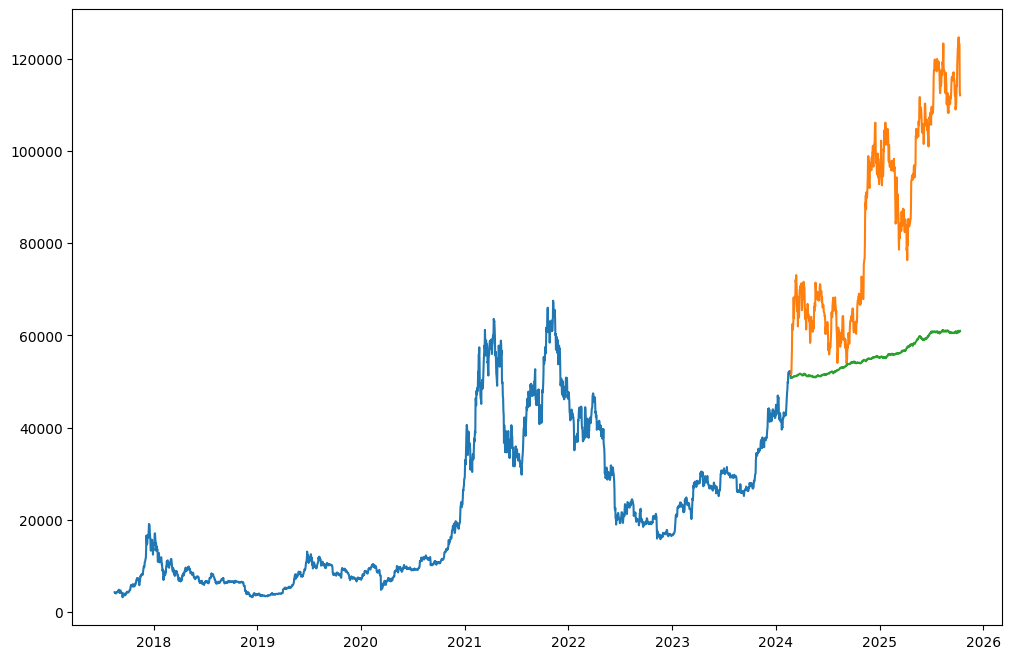

In [ ]:
fig, ax = plt.subplots(1, 1)
ax.plot(train['price'])
ax.plot(test['price'])
ax.plot(forecast_df['mean_numerical'])

# ax.fill_between(forecast_df.index, forecast_df['pi_lower'], forecast_df['pi_upper'], color='red', alpha=0.2)

In [ ]:
from statsforecast import StatsForecast
from statsforecast.models import AutoETS

pipeline = StatsForecast(
    models=[AutoETS(model="MMM", damped=True, season_length=7)],
    freq='D',
    n_jobs=-1
)

In [ ]:
train_df = pd.DataFrame(
    {

        'ds': train.index,
        'y': train['price'],
        'unique_id':'train'
    }
)
test_df = pd.DataFrame(
    {

        'ds': test.index,
        'y': test['price'],
        'unique_id':'test'
    }
)
test_df

pipeline.fit(train_df)

StatsForecast(models=[AutoETS])

In [ ]:
forecast_df = pipeline.predict(len(test))
forecast_df

,unique_id,ds,AutoETS
0,train,2024-02-24,50865.560724
1,train,2024-02-25,50940.134134
2,train,2024-02-26,51013.322149
3,train,2024-02-27,51085.148421
4,train,2024-02-28,51155.636283
...,...,...,...
591,train,2025-10-07,54731.332344
592,train,2025-10-08,54731.332868
593,train,2025-10-09,54731.333380
594,train,2025-10-10,54731.333883


In [ ]:
pipeline.fitted_[0, 0].model_['method']

'ETS(M,Md,M)'

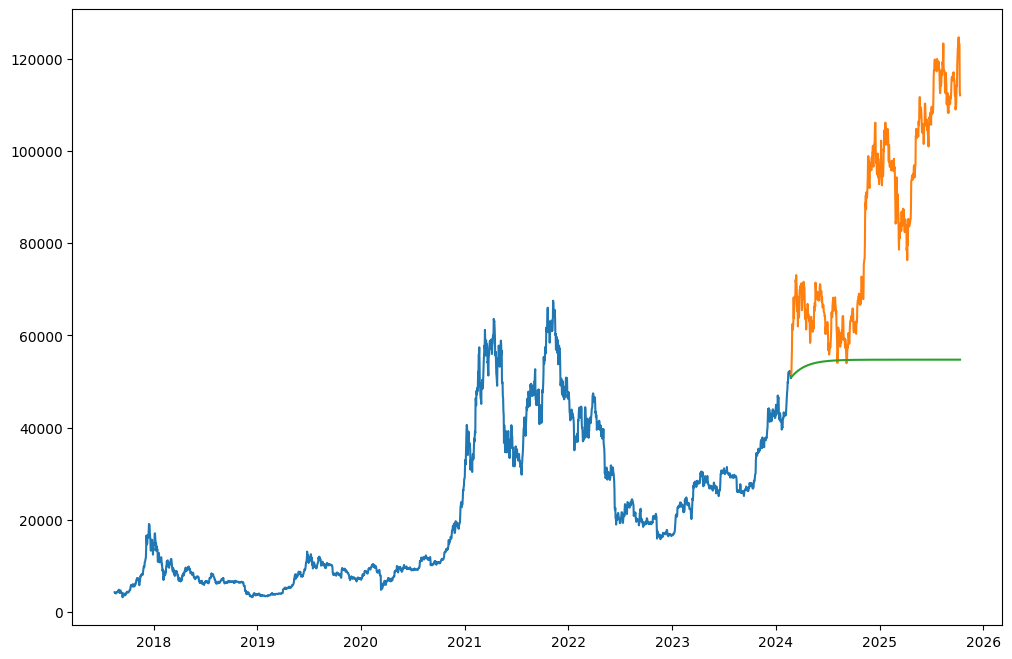

In [ ]:
fig, ax = plt.subplots(1, 1)
ax.plot(train_df['ds'], train_df['y'])
ax.plot(test_df['ds'], test_df['y'])
ax.plot(forecast_df['ds'], forecast_df['AutoETS'])

